In [1]:
%pip install pandas nltk sacrebleu rouge-score sentence-transformers bert-score numpy matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import torch
import json

import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from transformers import pipeline
from sentence_transformers import SentenceTransformer, util
from sacrebleu.metrics import BLEU as SacreBLEU
from rouge_score import rouge_scorer

/Users/xk84vl/Documents/Repos/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/xk84vl/Documents/Repos/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# SETUP
application = "iot"
base_model_dir = f"threat_templates/{application}"
models = ["gpt_5_1", "gemini_2_5_pro", "qwen_3_235b_thinking"]
results_dir = f"results/{application}"
stats_dir = f"stats/{application}"

os.makedirs(results_dir, exist_ok=True)
os.makedirs(stats_dir, exist_ok=True)

In [4]:
def load_json(file_path):
    return pd.read_json(file_path)

In [5]:
# Domain models
DOMAIN_MODELS = [
    "cisco-ai/SecureBERT2.0-base",
    "selfconstruct3d/AttackGroup-MPNET",
    "attack-vector/SecureModernBERT-NER",
    "ibm-research/CTI-BERT",
    "basel/ATTACK-BERT"
]

with open(f"{base_model_dir}/assets.json", "r") as f:
    assets = json.load(f)
assets = [asset.lower() for asset in assets]

# Cache the models
domain_embeddings = {name: SentenceTransformer(name) for name in DOMAIN_MODELS}

# Load NLI model
nli_model = pipeline("text-classification", model="roberta-large-mnli", return_all_scores=True)

def compute_text_metrics(base_threat, model_threat):
    # Overlapping assets
    in_base = [asset for asset in assets if asset in base_threat.lower()]
    in_model = [asset for asset in assets if asset in model_threat.lower()]
    if not in_base and not in_model:
        assets_overlap = -1
        assets_overlap_pct = -1
    else: 
        assets_overlap = len(set(in_base).intersection(set(in_model)))
        assets_overlap_pct = assets_overlap / len(set(in_base).union(set(in_model)))
    
    # SacreBLEU
    sbleu = SacreBLEU().corpus_score([model_threat], [[base_threat]]).score

    # ROUGE-L
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rouge = scorer.score(base_threat, model_threat)['rougeL'].fmeasure

    # Semantic similarity with domain models
    sim_scores = {}
    sim_avg = 0
    for name, model in domain_embeddings.items():
        emb1 = model.encode(base_threat, convert_to_tensor=True)
        emb2 = model.encode(model_threat, convert_to_tensor=True)
        sim_score = util.cos_sim(emb1, emb2).item()
        sim_scores[f"Similarity_{name.split('/')[-1]}"] = float(sim_score)
        sim_avg += sim_score
        
    sim_avg /= len(domain_embeddings)

    # Entailment scores
    nli_input = f"{base_threat} {nli_model.tokenizer.sep_token} {model_threat}"
    nli_result = nli_model(nli_input)[0]  # list of dicts with label & score

    # Extract labels and raw scores
    labels = [r['label'].upper() for r in nli_result]
    raw_scores = torch.tensor([r['score'] for r in nli_result])

    # Softmax to get probabilities
    probs = F.softmax(raw_scores, dim=0)

    # Hard entailment: only if predicted label is ENTAILMENT
    hard_entailment = next((r['score'] for r in nli_result if r['label'].upper() == 'ENTAILMENT'), 0.0)

    # Contrastive entailment: P(ENTAILMENT) - P(CONTRADICTION)
    contrastive_entailment = float(probs[labels.index('ENTAILMENT')] - probs[labels.index('CONTRADICTION')])

    results = {
        "overlap": assets_overlap,
        "overlap_pct": assets_overlap_pct,
        "bleu": sbleu,
        "rouge": rouge,
        "entailment": hard_entailment,
        "contrastive": contrastive_entailment,
        "similarity": sim_avg,
        **sim_scores
    }

    return results

No sentence-transformers model found with name cisco-ai/SecureBERT2.0-base. Creating a new one with mean pooling.
No sentence-transformers model found with name selfconstruct3d/AttackGroup-MPNET. Creating a new one with mean pooling.
No sentence-transformers model found with name attack-vector/SecureModernBERT-NER. Creating a new one with mean pooling.
No sentence-transformers model found with name ibm-research/CTI-BERT. Creating a new one with mean pooling.
Some weights of BertModel were not initialized from the model checkpoint at ibm-research/CTI-BERT and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassific

In [6]:
def merge_and_score_threats(base_df, model_df):
    results = []

    for _, row1 in base_df.iterrows():
        for _, row2 in model_df.iterrows():
            # Match Category/Threat Type
            if row1['Category'] == row2['Category']:
                base_threat = row1['Threat']
                model_threat = row2['Threat']

                metrics = compute_text_metrics(base_threat, model_threat)

                results.append({
                    "Category": row1['Category'],
                    "Base": base_threat,
                    "Model": model_threat,
                    **metrics
                })

    return pd.DataFrame(results)

def merge_and_score_mitigations(base_df, model_df, similar_df):
    results = []

    for _, row1 in base_df.iterrows():
        for _, row2 in model_df.iterrows():
            # Check if mitigation pair is in similar threats
            if ((similar_df['Base'] == row1['Threat']) & (similar_df['Model'] == row2['Threat'])).any():
                base_mitigation = row1['Mitigation']
                model_mitigation = row2['Mitigation']

                metrics = compute_text_metrics(base_mitigation, model_mitigation)

                results.append({
                    "Category": row1['Category'],
                    "Base": base_mitigation,
                    "Model": model_mitigation,
                    **metrics
                })

    return pd.DataFrame(results)

def merge_and_score_risk(base_df, model_df, similar_df):
    results = []

    for _, row1 in base_df.iterrows():
        for _, row2 in model_df.iterrows():
            # Check if mitigation pair is in similar threats
            if ((similar_df['Base'] == row1['Threat']) & (similar_df['Model'] == row2['Threat'])).any():
                base_mitigation = row1['Risk']
                model_mitigation = row2['Risk']

                metrics = compute_text_metrics(base_mitigation, model_mitigation)

                results.append({
                    "Category": row1['Category'],
                    "Base": base_mitigation,
                    "Model": model_mitigation,
                    **metrics
                })

    return pd.DataFrame(results)

In [7]:
def visualize_scores(df, metrics, title="Threat Similarity Metrics"):

    # Extract values for the metrics
    data = df[metrics].values

    num_items = data.shape[0]
    num_metrics = len(metrics)

    # Set bar positions
    x = np.arange(num_metrics)
    width = 0.8 / num_items  # adjust bar width based on number of rows

    plt.figure(figsize=(12, 6))

    for i in range(num_items):
        plt.bar(
            x + i * width,
            data[i],
            width,
            label=f"Pair {i+1}"
        )

    # Formatting
    plt.xticks(x + width * (num_items - 1) / 2, metrics, rotation=45)
    plt.ylabel("Score")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [8]:
def get_similar_pairs_all_metrics(results_df, print_it=False, sbleu=1, rouge=0.1, bert=0.5):
    similar = results_df[
        (results_df['overlap'] != 0) &
        (results_df['rouge'] >= 0) &
        (results_df['similarity'] >= 0) &
        (results_df['entailment'] >= 0) &
        (results_df['contrastive'] >= 0)
    ]
    
    return similar

In [9]:
similar_threats_dfs = {}
similar_mitigations_dfs = {}
similar_risk_dfs = {}
common_threats = set()
for model in models:
    # COMPARE MODEL AND ORIGINAL MODEL
    original_df = load_json(f"{base_model_dir}/threat_model.json")
    model_df = load_json(f"{results_dir}/{model}_stridegpt_model.json")
    merged_model_df = merge_and_score_threats(original_df, model_df)
    
    # Retrieve similar pairs based on calculated metrics
    similar_df = get_similar_pairs_all_metrics(merged_model_df, print_it=True)
    similar_threats_dfs[model] = similar_df
    similar_df.to_json(f"{stats_dir}/{model}_similar_threats.json", orient="records", indent=2)
    
    # Print stats about similar pairs
    unique_threats = similar_df['Base'].unique()
    if len(common_threats) == 0:
        common_threats = set(unique_threats)
    else:
        common_threats.intersection(set(unique_threats))
    
    mitigation_df = merge_and_score_mitigations(original_df, model_df, similar_df)
    similar_mitigation = get_similar_pairs_all_metrics(mitigation_df, print_it=True)
    similar_mitigations_dfs[model] = similar_mitigation
    similar_mitigation.to_json(f"{stats_dir}/{model}_similar_mitigations.json", orient="records", indent=2)
    
    risk_df = merge_and_score_risk(original_df, model_df, similar_df)
    similar_risk = get_similar_pairs_all_metrics(risk_df, print_it=True)
    similar_risk_dfs[model] = similar_risk
    similar_risk.to_json(f"{stats_dir}/{model}_similar_risks.json", orient="records", indent=2)
    
    print(f"Model: {model}")
    print(f"Threats in base: {len(original_df)}")
    print(f"Threats in model: {len(model_df)}")
    print(f"Total similar pairs found: {len(similar_df)} out of {len(merged_model_df)}")
    print(f"Unique similar threats in model: {len(unique_threats)}")
    print(f"Similar mitigations found: {len(similar_mitigation)}")
    print(f"Similar risks found: {len(similar_risk)}")
    print("-" * 50)

Compiling the model with `torch.compile` and using a `torch.mps` device is not supported. Falling back to non-compiled mode.


Model: gpt_5_1
Threats in base: 12
Threats in model: 22
Total similar pairs found: 4 out of 42
Unique similar threats in model: 3
Similar mitigations found: 2
Similar risks found: 1
--------------------------------------------------
Model: gemini_2_5_pro
Threats in base: 12
Threats in model: 9
Total similar pairs found: 2 out of 19
Unique similar threats in model: 2
Similar mitigations found: 1
Similar risks found: 2
--------------------------------------------------
Model: qwen_3_235b_thinking
Threats in base: 12
Threats in model: 16
Total similar pairs found: 3 out of 30
Unique similar threats in model: 3
Similar mitigations found: 0
Similar risks found: 1
--------------------------------------------------


In [10]:
# Find overlapping threats between different models
print(f"Threats in base model: {len(original_df)}")
print(f"Total number of overlapping threats between the different models': {len(common_threats)}")

Threats in base model: 12
Total number of overlapping threats between the different models': 3


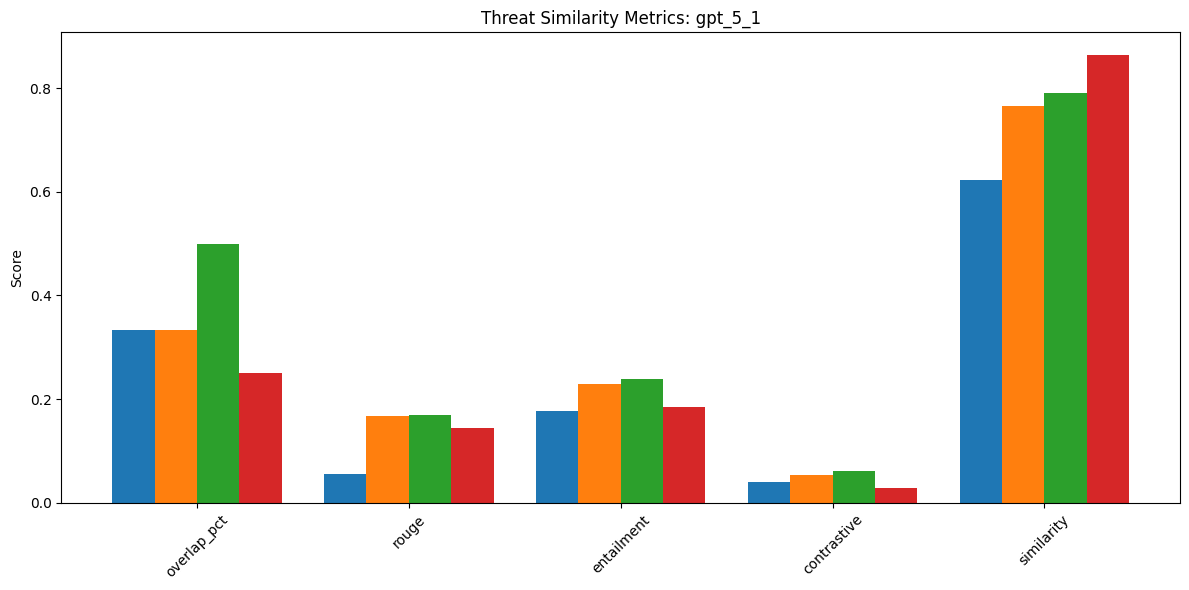

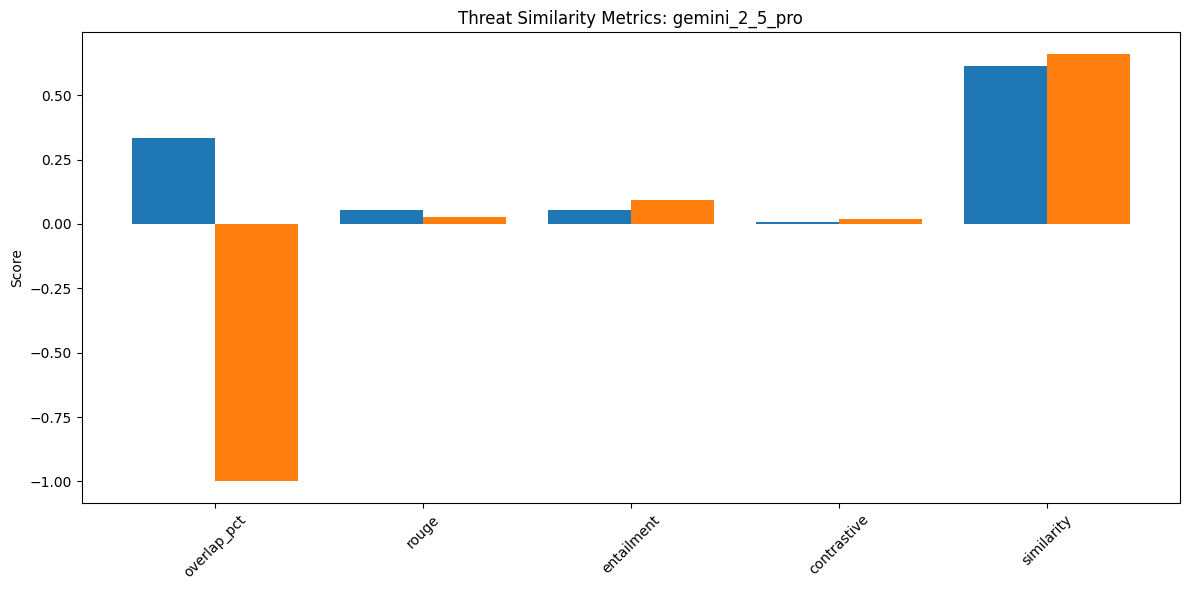

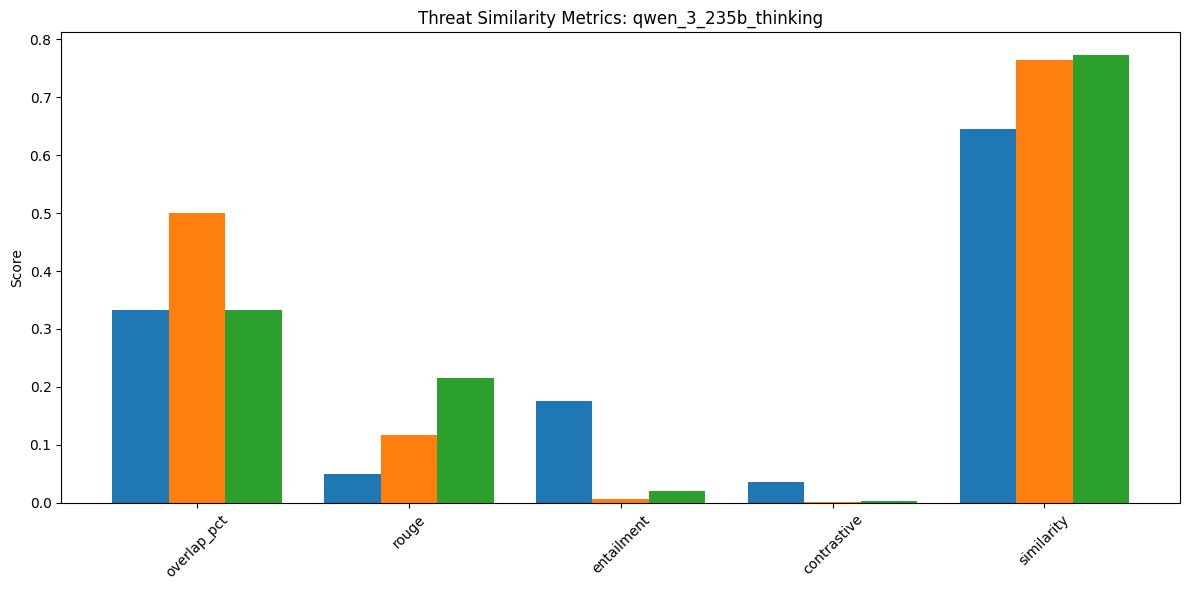

In [ ]:
metrics = [
    "overlap_pct",
    "rouge",
    "entailment",
    "contrastive",
    "similarity",
]
for model, similar_df in similar_threats_dfs.items():
    if len(similar_df) != 0:
        visualize_scores(similar_df, metrics, title=f"Threat Similarity Metrics: {model}")

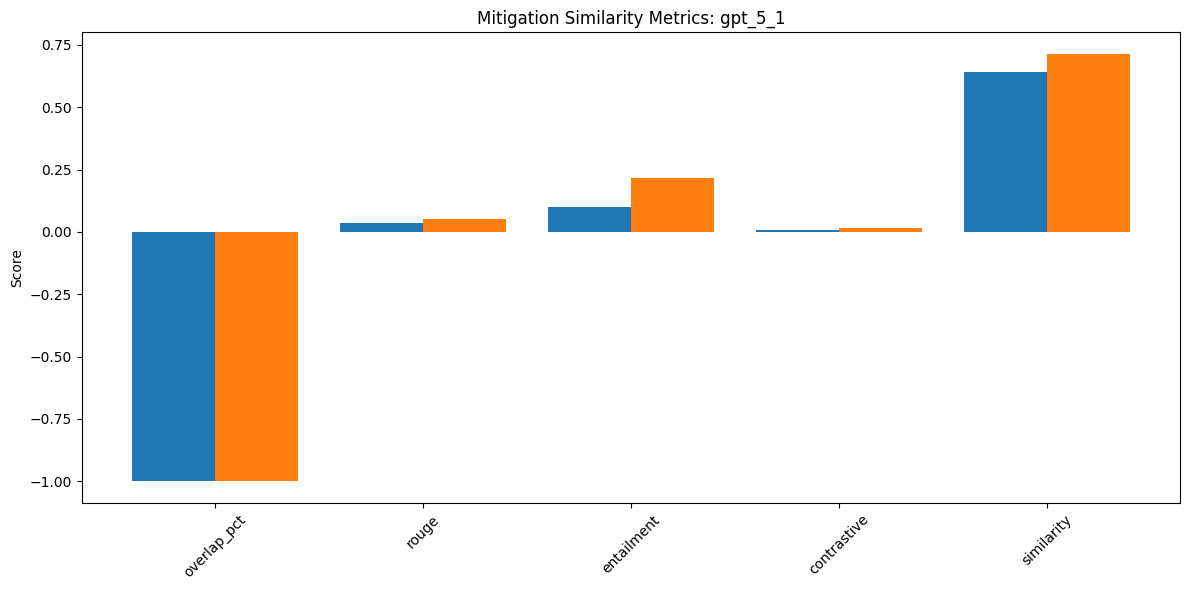

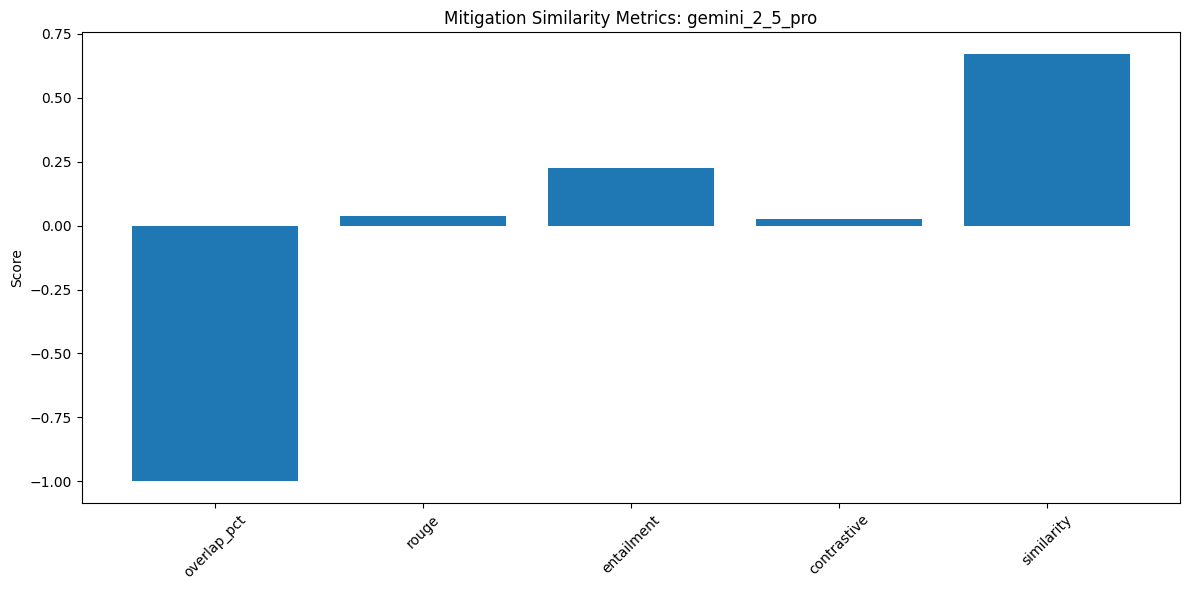

In [13]:
metrics = [
    "overlap_pct",
    "rouge",
    "entailment",
    "contrastive",
    "similarity",
]
for model, similar_df in similar_mitigations_dfs.items():
    if len(similar_df) != 0:
        visualize_scores(similar_df, metrics, title=f"Mitigation Similarity Metrics: {model}")

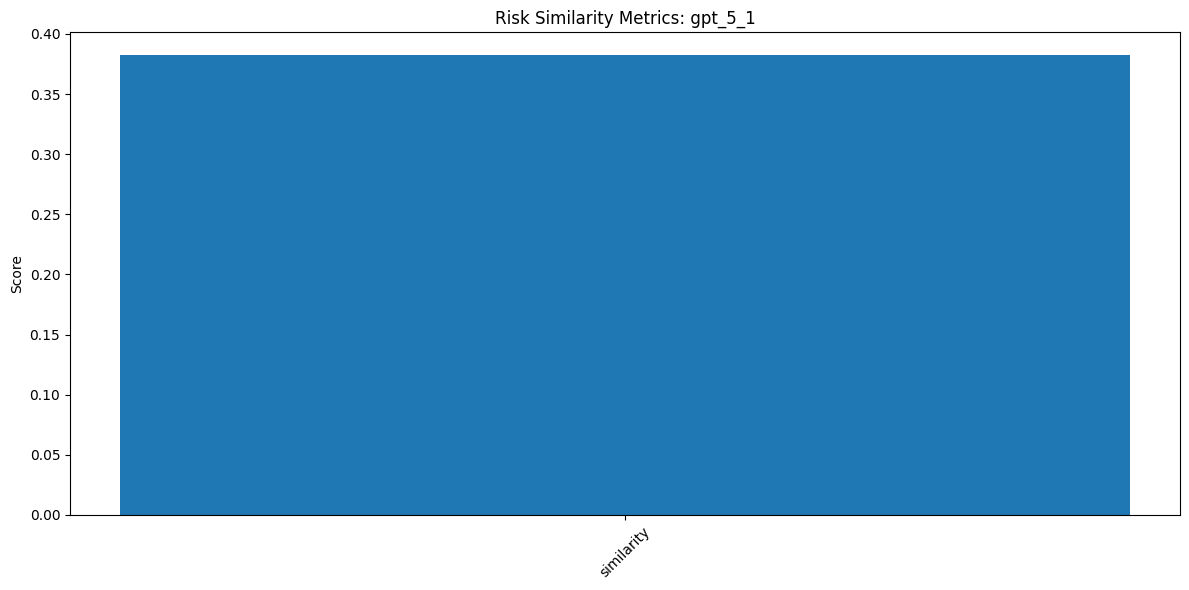

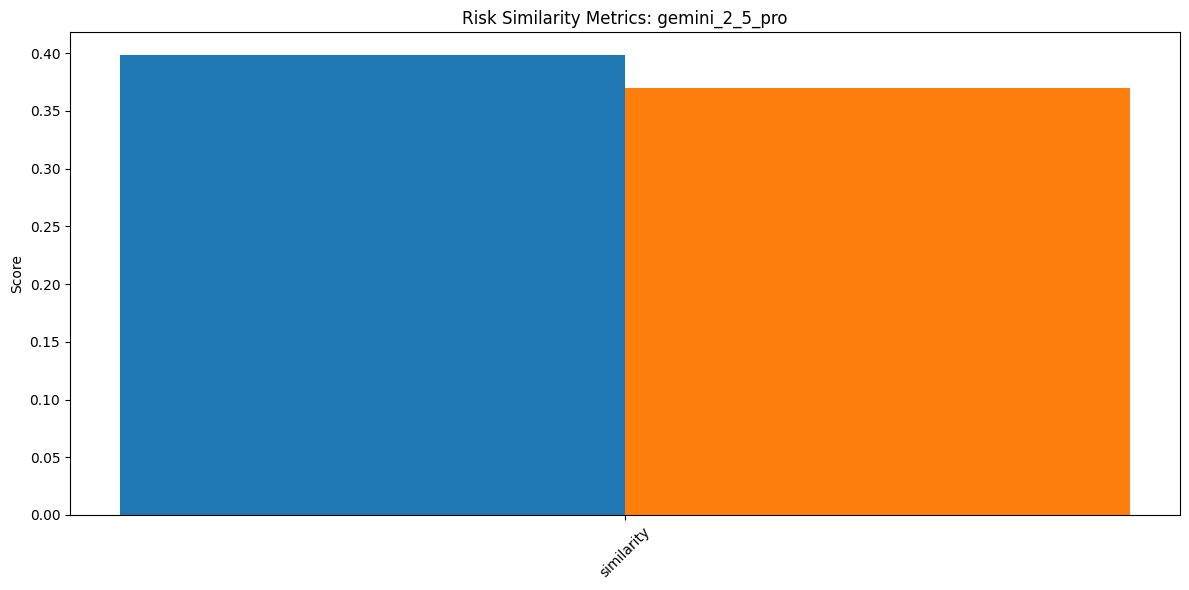

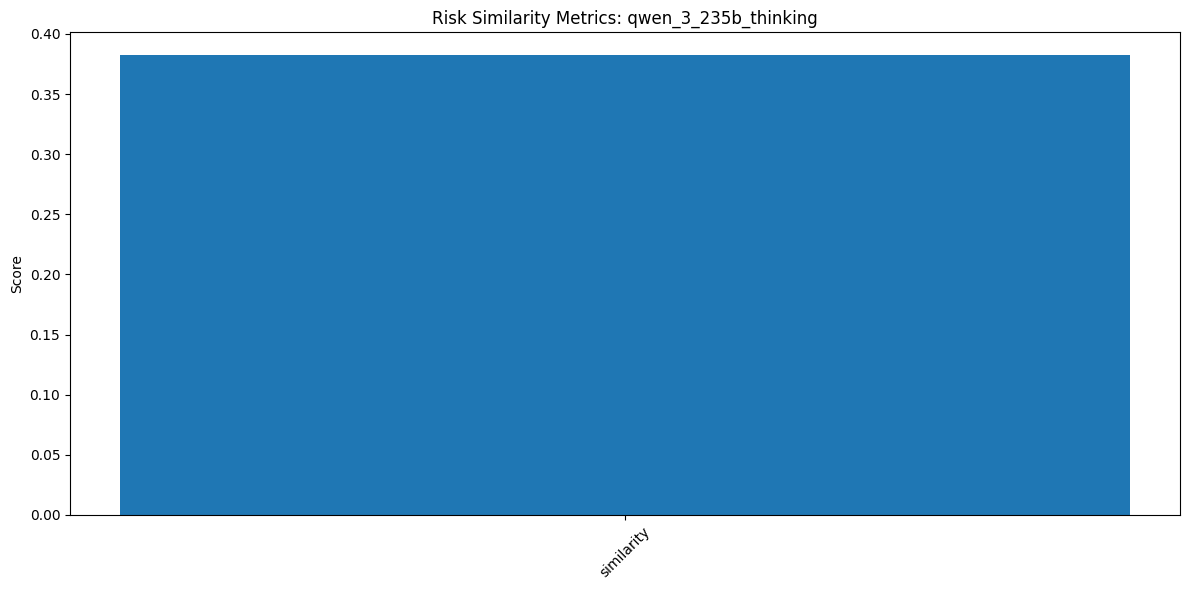

In [ ]:
metrics = [
    "similarity",
]
for model, similar_df in similar_risk_dfs.items():
    if len(similar_df) != 0:
        visualize_scores(similar_df, metrics, title=f"Risk Similarity Metrics: {model}")